# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 5 — Mean-stress effects, Miner's rule and S–N estimation

- [Exercise 5.1](#ex1) — Soderberg diagram for a forged steel
- [Exercise 5.2](#ex2) — Effect of mean stress on specimen ranking
- [Exercise 5.3](#ex3) — S–N (EC3) and effect of stress reduction
- [Exercise 5.4](#ex4) — Miner's rule: AISI 1045 steel
- [Exercise 5.5](#ex5) — Miner's rule: shortcomings
- [Exercise 5.6](#ex6) — Estimating the S–N curve from $\sigma_u$
- [Exercise 5.7](#ex7) — Residual stresses


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})

COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085', soft='#2980b9')


---

## Formulary — Mean-stress correction and damage accumulation

**Soderberg:**
\begin{equation*}
\dfrac{\sigma_a}{\sigma_{f0}} + \dfrac{\sigma_m}{\sigma_e} = 1
\tag{F.1}\end{equation*}

**Goodman:**
\begin{equation*}
\dfrac{\sigma_a}{\sigma_{f0}} + \dfrac{\sigma_m}{\sigma_u} = 1
\tag{F.2}\end{equation*}

**Gerber:**
\begin{equation*}
\dfrac{\sigma_a}{\sigma_{f0}} + \left(\dfrac{\sigma_m}{\sigma_u}\right)^{\!2} = 1
\tag{F.3}\end{equation*}

**Modified Basquin (mean-stress correction):**
\begin{equation*}
\sigma_a = (\sigma_f' - \sigma_m)\,(2N_f)^{b}
\tag{F.4}\end{equation*}

**Miner's rule:**
\begin{equation*}
D = \sum_{i=1}^{k}\dfrac{n_i}{N_{f,i}}\le 1
\tag{F.5}\end{equation*}


<a id='ex1'></a>
---

## Exercise 5.1 — Soderberg diagram for a forged steel

A forged steel has $\sigma_e = 386$ MPa, $\sigma_u = 620$ MPa, and fatigue limit (unnotched, $R=-1$) $\sigma_{f0} = 296$ MPa.

(a) Construct the Soderberg diagram ($\sigma_a$ vs. $\sigma_m$).

(b) Determine the fatigue limit (amplitude) for a loading with $\sigma_m = \sigma_a/2$.

(c) Determine the fatigue limit for a pulsating loading ($R = 0$, i.e. $\sigma_{\min} = 0$).

(d) On the same diagram, construct the Goodman and Gerber lines. Compare the predictions for parts (b) and (c).

### Solution


#### (a) Soderberg diagram

The straight line from $(0,\sigma_{f0})$ to $(\sigma_e,0)$ defines the
safe-life envelope (F.1).


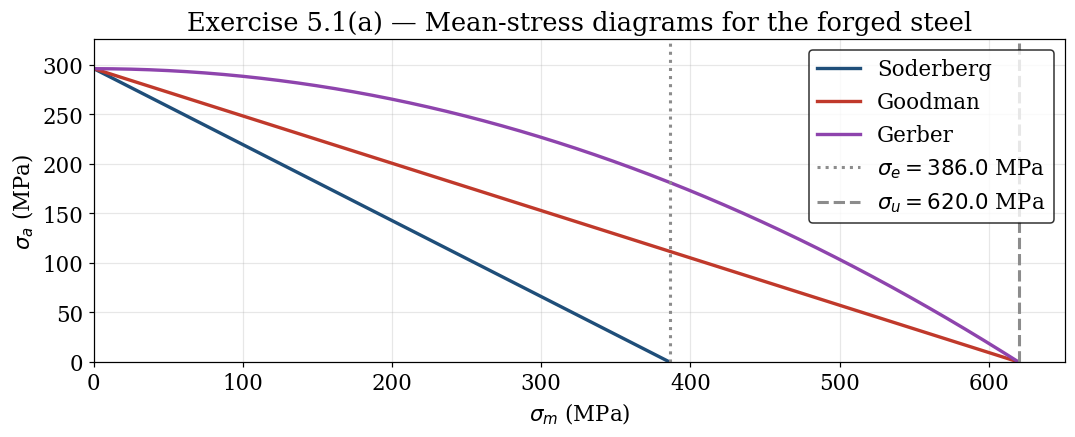

In [2]:
sigma_e, sigma_u, sigma_f0 = 386.0, 620.0, 296.0
sm = np.linspace(0, max(sigma_e, sigma_u), 400)

sa_soder = sigma_f0*(1 - sm/sigma_e);       sa_soder = np.where(sa_soder>=0, sa_soder, np.nan)
sa_good  = sigma_f0*(1 - sm/sigma_u);       sa_good  = np.where(sa_good>=0,  sa_good,  np.nan)
sa_gerb  = sigma_f0*(1 - (sm/sigma_u)**2);  sa_gerb  = np.where(sa_gerb>=0,  sa_gerb,  np.nan)

fig, ax = plt.subplots()
ax.plot(sm, sa_soder, color=COLORS['curve'], lw=2.2, label='Soderberg')
ax.plot(sm, sa_good,  color=COLORS['point'], lw=2.2, label='Goodman')
ax.plot(sm, sa_gerb,  color=COLORS['accent'],lw=2.2, label='Gerber')
ax.axvline(sigma_e, color=COLORS['guide'], ls=':', label=fr'$\sigma_e={sigma_e}$ MPa')
ax.axvline(sigma_u, color=COLORS['guide'], ls='--',label=fr'$\sigma_u={sigma_u}$ MPa')
ax.set_xlabel(r'$\sigma_m$ (MPa)'); ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_xlim(0, sigma_u*1.05); ax.set_ylim(0, sigma_f0*1.1)
ax.set_title('Exercise 5.1(a) — Mean-stress diagrams for the forged steel')
ax.legend(); plt.tight_layout(); plt.show()


#### (b) $\sigma_m=\sigma_a/2$ — fatigue limit by Soderberg

Substitute $\sigma_m=\sigma_a/2$ in (F.1):

\begin{equation*}
\dfrac{\sigma_a}{\sigma_{f0}} + \dfrac{\sigma_a/2}{\sigma_e} = 1
\quad\Longrightarrow\quad
\sigma_a = \dfrac{1}{1/\sigma_{f0} + 1/(2\sigma_e)}.
\tag{5.1.1}\end{equation*}


In [3]:
sa_b_soder = 1/(1/sigma_f0 + 1/(2*sigma_e))
sa_b_good  = 1/(1/sigma_f0 + 1/(2*sigma_u))
# Gerber: σ_a/σ_f0 + (σ_a/2/σ_u)² = 1 → quadratic  [c2, c1, c0]·σ_a^n = 0
roots = np.roots([(1/(2*sigma_u))**2, 1/sigma_f0, -1])
sa_b_gerb = float(roots[roots>0].min())
print(f'(b) σ_m = σ_a/2:')
print(f'    Soderberg : σ_a = {sa_b_soder:.2f} MPa  (σ_m = {sa_b_soder/2:.2f} MPa)')
print(f'    Goodman   : σ_a = {sa_b_good:.2f} MPa  (σ_m = {sa_b_good/2:.2f} MPa)')
print(f'    Gerber    : σ_a = {sa_b_gerb:.2f} MPa  (σ_m = {sa_b_gerb/2:.2f} MPa)')

(b) σ_m = σ_a/2:
    Soderberg : σ_a = 213.96 MPa  (σ_m = 106.98 MPa)
    Goodman   : σ_a = 238.96 MPa  (σ_m = 119.48 MPa)
    Gerber    : σ_a = 280.82 MPa  (σ_m = 140.41 MPa)


#### (c) Pulsating loading $R=0$: $\sigma_m=\sigma_a$

Substitute in (F.1):

\begin{equation*}
\sigma_a = \dfrac{1}{1/\sigma_{f0} + 1/\sigma_e}.
\tag{5.1.2}\end{equation*}


Para o caso específico **R = 0**, onde:

$$
\sigma_m=\sigma_a
$$

Na relação de Gerber:

$$
\frac{\sigma_a}{\sigma_{f0}}+\left(\frac{\sigma_m}{\sigma_u}\right)^2=1
$$

como $\sigma_m=\sigma_a$, fica:

$$
\frac{\sigma_a}{\sigma_{f0}}+\left(\frac{\sigma_a}{\sigma_u}\right)^2=1
$$

ou seja, uma equação quadrática:

$$
\left(\frac{1}{\sigma_u}\right)^2\sigma_a^2+
\frac{1}{\sigma_{f0}}\sigma_a-1=0
$$

Logo, em python pode-se implementar:

```python
roots = np.roots([(1/sigma_u)**2, 1/sigma_f0, -1])
real_roots = roots[np.isreal(roots)].real
sa_c_gerb = real_roots[real_roots > 0].min()
```

In [4]:
sa_c_soder = 1/(1/sigma_f0 + 1/sigma_e)
sa_c_good  = 1/(1/sigma_f0 + 1/sigma_u)
roots = np.roots([(1/sigma_u)**2, 1/sigma_f0, -1])
sa_c_gerb  = float(roots[roots>0].min())
print(f'(c) R = 0 (σ_m = σ_a):')
print(f'    Soderberg : σ_a = {sa_c_soder:.2f} MPa')
print(f'    Goodman   : σ_a = {sa_c_good:.2f} MPa')
print(f'    Gerber    : σ_a = {sa_c_gerb:.2f} MPa')


(c) R = 0 (σ_m = σ_a):
    Soderberg : σ_a = 167.53 MPa
    Goodman   : σ_a = 200.35 MPa
    Gerber    : σ_a = 248.46 MPa


#### (d) Comparison of the three criteria

Soderberg is the most conservative (uses $\sigma_e$); Gerber the least
conservative (quadratic envelope, anchored at $\sigma_u$); Goodman lies in
between. Differences grow with $\sigma_m$.


#### Solution summary — Exercise 5.1

| Criterion | $\sigma_a$ for $\sigma_m = \sigma_a/2$ (MPa) | $\sigma_a$ for $R=0$, $\sigma_m=\sigma_a$ (MPa) |
|---|---:|---:|
| Soderberg | 213.96 | 167.53 |
| Goodman   | 238.96 | 200.35 |
| Gerber    | 280.82 | 248.46 |

Soderberg is the most conservative (uses $\sigma_e$ as the mean-stress limit); Gerber is the least conservative (quadratic envelope anchored at $\sigma_u$). Differences grow with increasing $\sigma_m$.

<a id='ex2'></a>
---

## Exercise 5.2 — Effect of mean stress on specimen ranking

Three identical fatigue specimens (A, B, C) of a non-ferrous alloy are tested under the conditions shown:

| Specimen | $\sigma_{\max}$ (MPa) | $\sigma_{\min}$ (MPa) |
|---|---:|---:|
| A | $+450$ | $-150$ |
| B | $+300$ | $-300$ |
| C | $+500$ | $-200$ |

(a) Compute $\sigma_m$ and $\sigma_a$ for each specimen.

(b) Rank the specimens from longest to shortest fatigue life. Justify using a Soderberg-type argument.

(c) Sketch two S--N curves (for two different $\sigma_m$ values) and locate the three test points.

### Solution


In [5]:
data = {
    'A': (+450, -150),
    'B': (+300, -300),
    'C': (+500, -200),
}
print(f'{"":3s} {"σ_max":>6s} {"σ_min":>6s} {"σ_m":>6s} {"σ_a":>6s} {"R":>7s}')
res = {}
for k,(sm_,sn_) in data.items():
    sm  = (sm_ + sn_)/2; sa = (sm_ - sn_)/2; R = sn_/sm_
    res[k] = (sm, sa, R)
    print(f'{k:3s} {sm_:6.0f} {sn_:6.0f} {sm:6.0f} {sa:6.0f} {R:+7.3f}')


     σ_max  σ_min    σ_m    σ_a       R
A      450   -150    150    300  -0.333
B      300   -300      0    300  -1.000
C      500   -200    150    350  -0.400


#### (b) Soderberg-type ranking

The "Soderberg distance to failure" is
$\rho_{\text{Sod}} = \sigma_a/\sigma_{f0} + \sigma_m/\sigma_e$ — values
**closer to 1** mean shorter life. For a single non-ferrous alloy we don't
know $\sigma_{f0},\sigma_e$ numerically, but the *relative ordering* of
$\rho$ is unchanged. Empirically (Schijve §6.2): in this regime $\sigma_a$
dominates, with $\sigma_m$ as a secondary effect.

Using $\sigma_a$ as the primary driver, then breaking ties by $\sigma_m$:

| Specimen | $\sigma_a$ | $\sigma_m$ | rank |
|---|---|---|---|
| A | 300 | 150 | 2 |
| B | 300 | 0   | **1 (longest life)** |
| C | 350 | 150 | 3 (shortest life) |

B has same $\sigma_a$ as A but $\sigma_m=0$ → longer life.
A and C have same $\sigma_m$ but C has higher $\sigma_a$ → shorter than A.

**Ranking** (longest → shortest): **B > A > C**.

#### (c) Sketch S–N curves

Two S–N curves: one for $\sigma_m=0$ (B), another for $\sigma_m=150$ (A and C).
The $\sigma_m=150$ curve sits below the $\sigma_m=0$ curve (mean-stress
correction shifts the curve downward).


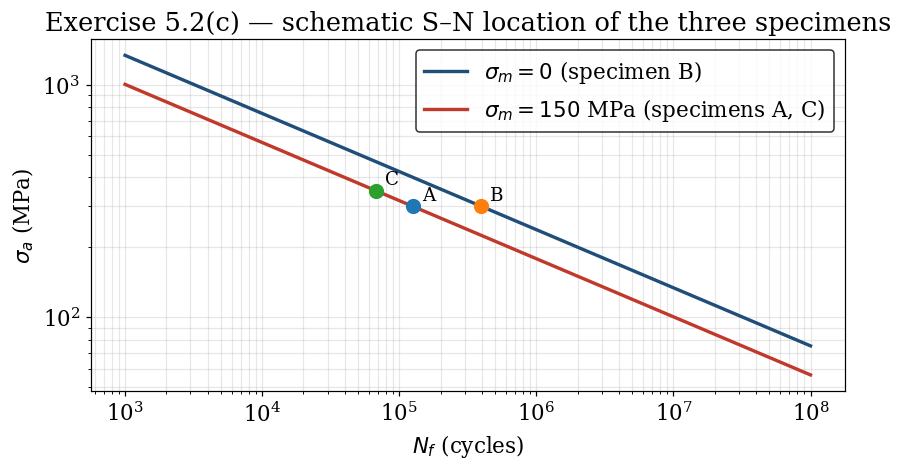

In [6]:
# Schematic — show how the three specimens lie on two S-N curves

m_SN = 4.0

def Nf_baseline(sigma_a):
    # baseline so that σ_a = 200 MPa gives 2e6 cycles
    return 2e6 * (200.0 / sigma_a)**m_SN

mean_stress_factor = 0.75   # reduction of fatigue strength for σ_m = 150 MPa

def Nf_meanstress(sigma_a):
    # reduced S-N curve due to tensile mean stress
    return 2e6 * (mean_stress_factor * 200.0 / sigma_a)**m_SN

x = np.logspace(3, 8, 400)

y_blue = 200.0 * (2e6 / x)**(1.0 / m_SN)
y_red  = mean_stress_factor * 200.0 * (2e6 / x)**(1.0 / m_SN)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.loglog(x, y_blue, color=COLORS['curve'], lw=2.2,
          label=r'$\sigma_m = 0$ (specimen B)')

ax.loglog(x, y_red, color=COLORS['point'], lw=2.2,
          label=r'$\sigma_m = 150$ MPa (specimens A, C)')

for k, (_, sa, _) in res.items():
    if k == 'B':
        Nfk = Nf_baseline(sa)
    else:
        Nfk = Nf_meanstress(sa)

    ax.scatter(Nfk, sa, s=80, zorder=5)
    ax.annotate(k, (Nfk, sa), xytext=(6, 4),
                textcoords='offset points', fontsize=12)

ax.set_xlabel(r'$N_f$ (cycles)')
ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_title('Exercise 5.2(c) — schematic S–N location of the three specimens')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

#### Solution summary — Exercise 5.2

| Specimen | $\sigma_{\max}$ (MPa) | $\sigma_{\min}$ (MPa) | $\sigma_m$ (MPa) | $\sigma_a$ (MPa) | $R$ |
|---|---:|---:|---:|---:|---:|
| A | 450 | −150 | 150 | 300 | −0.333 |
| B | 300 | −300 |   0 | 300 | −1.000 |
| C | 500 | −200 | 150 | 350 | −0.400 |

**Ranking (longest → shortest life): B > A > C.**

B and A share the same $\sigma_a = 300$ MPa but B has $\sigma_m = 0$ → longer life.
A and C share the same $\sigma_m = 150$ MPa but C has higher $\sigma_a = 350$ MPa → shorter life.

<a id='ex3'></a>
---

## Exercise 5.3 — S–N (EC3, FAT 160) and effect of stress reduction


Using the EC3 S--N curve from Week 1 ($m = 3$, $\Delta\sigma_D = 160$ MPa):

(a) A component operates at $\Delta\sigma = 300$ MPa. Compute $N_f$.

(b) If the stress range is reduced by 10% (to $270$ MPa), compute the new $N_f$ and the percentage increase in life.

(c) Generalise: plot the percentage increase in $N_f$ as a function of the percentage reduction in $\Delta\sigma$ (from 0 to 20%), starting from $300$ MPa. Comment on the non-linear sensitivity.

### Solution


In [7]:
m_SN = 3.0
Dsigma_ref, Nf_ref = 160.0, 2.0e6
C_SN = Dsigma_ref**m_SN * Nf_ref      # MPa^3

Ds1 = 300.0
Nf1 = C_SN/Ds1**m_SN
print(f'(a) N_f(300 MPa) = {Nf1:.3e} cycles')

Ds2 = 270.0
Nf2 = C_SN/Ds2**m_SN
print(f'(b) N_f(270 MPa) = {Nf2:.3e} cycles  ({(Nf2-Nf1)/Nf1*100:+.1f}%)')


(a) N_f(300 MPa) = 3.034e+05 cycles
(b) N_f(270 MPa) = 4.162e+05 cycles  (+37.2%)


#### (c) Generalised sensitivity


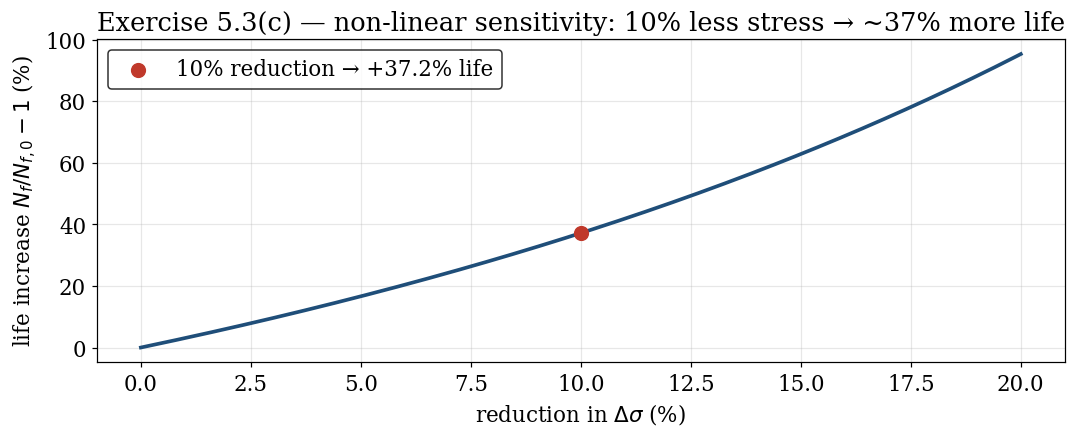

In [8]:
reduction = np.linspace(0, 20, 200)             # %
Ds = 300.0*(1 - reduction/100)
Nf = C_SN/Ds**m_SN
increase = (Nf/Nf1 - 1)*100
fig, ax = plt.subplots()
ax.plot(reduction, increase, color=COLORS['curve'], lw=2.4)
ax.scatter([10], [(Nf2-Nf1)/Nf1*100], color=COLORS['point'], s=80, zorder=5,
           label=f'10% reduction → +{(Nf2-Nf1)/Nf1*100:.1f}% life')
ax.set_xlabel(r'reduction in $\Delta\sigma$ (%)')
ax.set_ylabel(r'life increase $N_f/N_{f,0}-1$ (%)')
ax.set_title('Exercise 5.3(c) — non-linear sensitivity: 10% less stress → ~37% more life')
ax.legend(); plt.tight_layout(); plt.show()


#### Solution summary — Exercise 5.3

| Quantity | Value |
|---|---:|
| $N_f(\Delta\sigma = 300\ \text{MPa})$ | $3.034 \times 10^5$ cycles |
| $N_f(\Delta\sigma = 270\ \text{MPa})$ | $4.162 \times 10^5$ cycles |
| Life increase for 10 % stress reduction | $+37.2\%$ |

Life scales as $N_f \propto \Delta\sigma^{-m}$ with $m = 3$, so a 10 % stress reduction multiplies life
by $(1/0.9)^3 \approx 1.37$ — a strongly non-linear gain that rewards even small stress-reduction measures.

<a id='ex4'></a>

---

## Exercise 5.4 — Miner’s rule: AISI 1045 steel


An AISI 1045 steel component is subjected to the following block loading spectrum ($\sigma_f' = 1198.6$ MPa, $b = -0.09$; modified Basquin with mean stress correction):

| Block | $\sigma_{\max}$ (MPa) | $\sigma_{\min}$ (MPa) | $\sigma_m$ (MPa) | $n$ (cycles) |
|---|---:|---:|---:|---:|
| 1 | $+450$ | $-150$ | $+150$ | 300 000 |
| 2 | $+300$ | $-300$ | $0$ | 150 000 |
| 3 | $+500$ | $-200$ | $+150$ | 30 000 |

(a) For each block, compute $\sigma_a$ and $N_{f,i}$ using the modified Basquin relation.

(b) Compute the cumulative Miner damage $D = \sum n_i / N_{f,i}$.

(c) Does the component survive the applied spectrum? If so, how many more identical spectra could be applied before failure?

### Solution

For variable-amplitude fatigue loading, each load block consumes a fraction
of the component fatigue life. Miner’s linear damage rule assumes that these
fractions accumulate linearly:

$$
D = \sum_{i=1}^{k}\frac{n_i}{N_{f,i}}
$$

where:

- $n_i$ = number of cycles actually applied in block $i$,
- $N_{f,i}$ = fatigue life under that constant-amplitude loading alone,
- $D$ = accumulated fatigue damage.

Interpretation:

- $D < 1$ → specimen survives,
- $D \approx 1$ → fatigue failure expected,
- $D > 1$ → failure predicted.

The fatigue life for each block is estimated using the modified Basquin
relation with mean-stress correction:

$$
\sigma_a = (\sigma_f' - \sigma_m)(2N_f)^b
$$

with:

$$
\sigma_f' = 1198.6\ \text{MPa},
\qquad
b=-0.09
$$

The loading spectrum is:

| Block | $\sigma_{\max}$ | $\sigma_{\min}$ | $\sigma_m$ | $n$ (cycles) |
|---|---|---|---|---|
| 1 | $+450$ | $-150$ | $+150$ | 300 000 |
| 2 | $+300$ | $-300$ | $0$    | 150 000 |
| 3 | $+500$ | $-200$ | $+150$ | 30 000 |

### Step 1 — Compute stress amplitude

For each block:

$$
\sigma_a = \frac{\sigma_{\max}-\sigma_{\min}}{2}
$$

Thus:

| Block | $\sigma_a$ (MPa) |
|---|---|
| 1 | $300$ |
| 2 | $300$ |
| 3 | $350$ |

### Step 2 — Determine fatigue life for each block

Rearranging Basquin’s equation:

$$
N_f
=
\frac{1}{2}
\left(
\frac{\sigma_a}{\sigma_f'-\sigma_m}
\right)^{1/b}
$$

This gives the number of cycles the material would sustain if subjected
only to that loading block.

### Step 3 — Compute Miner damage for each block

For each block:

$$
D_i = \frac{n_i}{N_{f,i}}
$$

The total accumulated damage is:

$$
D = D_1 + D_2 + D_3
$$

### Step 4 — Failure assessment

- If $D < 1$, the loading history does not yet exhaust the fatigue life.
- If $D \approx 1$, fatigue failure is expected.
- The quantity $1/D$ may also be interpreted as an estimate of the
remaining life scaling factor for repeated spectra.

### Physical interpretation

Miner’s rule can be interpreted as a “fatigue life budget”:

- severe stress blocks consume life rapidly;
- mild stress blocks consume life slowly;
- the total fatigue damage is obtained by summing all partial damages.

Although simplified, this approach is widely used in engineering fatigue
assessment because of its simplicity and practical usefulness.

In [9]:
# ------------------------------------------------------------
# Exercise 5.4 — Miner's rule: AISI 1045 steel
# ------------------------------------------------------------

sigma_fp = 1198.6   # MPa
b = -0.09

blocks = [
    dict(name='B1', smax=450, smin=-150, n=300_000),
    dict(name='B2', smax=300, smin=-300, n=150_000),
    dict(name='B3', smax=500, smin=-200, n=30_000),
]

rows = []

for bl in blocks:
    sigma_m = (bl['smax'] + bl['smin']) / 2
    sigma_a = (bl['smax'] - bl['smin']) / 2

    # Modified Basquin:
    # σ_a = (σ_f' - σ_m)(2N_f)^b
    #
    # Rearranged:
    # N_f = 1/2 * [σ_a / (σ_f' - σ_m)]^(1/b)

    Nf = 0.5 * (sigma_a / (sigma_fp - sigma_m))**(1.0 / b)

    damage = bl['n'] / Nf

    rows.append({
        'Block': bl['name'],
        'σ_max [MPa]': bl['smax'],
        'σ_min [MPa]': bl['smin'],
        'σ_m [MPa]': sigma_m,
        'σ_a [MPa]': sigma_a,
        'n [cycles]': bl['n'],
        'N_f [cycles]': Nf,
        'Damage n/N_f': damage
    })

df = pd.DataFrame(rows)

D = df['Damage n/N_f'].sum()
life_factor = 1.0 / D

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(df.style.format({
    'σ_max [MPa]': '{:.0f}',
    'σ_min [MPa]': '{:.0f}',
    'σ_m [MPa]': '{:.0f}',
    'σ_a [MPa]': '{:.0f}',
    'n [cycles]': '{:,.0f}',
    'N_f [cycles]': '{:.3e}',
    'Damage n/N_f': '{:.4f}'
}))

print('\nMiner damage calculation')
print('------------------------')
print(f'D = Σ n_i/N_f,i = {D:.4f}')

if D >= 1:
    print('D ≥ 1 → failure is predicted during this loading spectrum.')
else:
    print('D < 1 → the component survives this loading spectrum.')
    print(f'Number of identical spectra to reach D = 1: {life_factor:.2f}')

,Block,σ_max [MPa],σ_min [MPa],σ_m [MPa],σ_a [MPa],n [cycles],N_f [cycles],Damage n/N_f
0,B1,450,-150,150,300,"300,000",5.467e+05,0.5488
1,B2,300,-300,0,300,"150,000",2.415e+06,0.0621
2,B3,500,-200,150,350,"30,000",9.860e+04,0.3043



Miner damage calculation
------------------------
D = Σ n_i/N_f,i = 0.9151
D < 1 → the component survives this loading spectrum.
Number of identical spectra to reach D = 1: 1.09


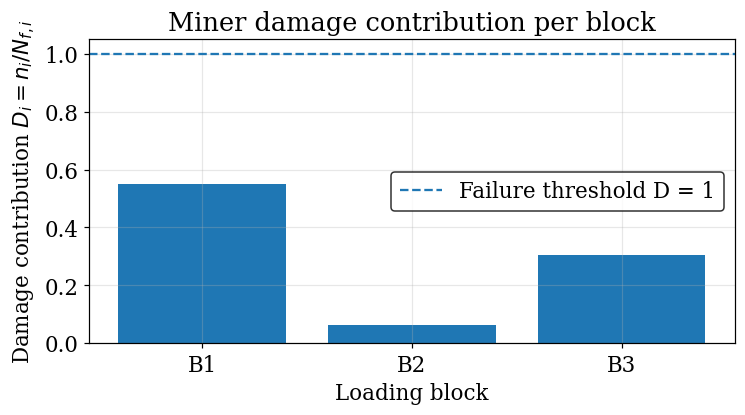

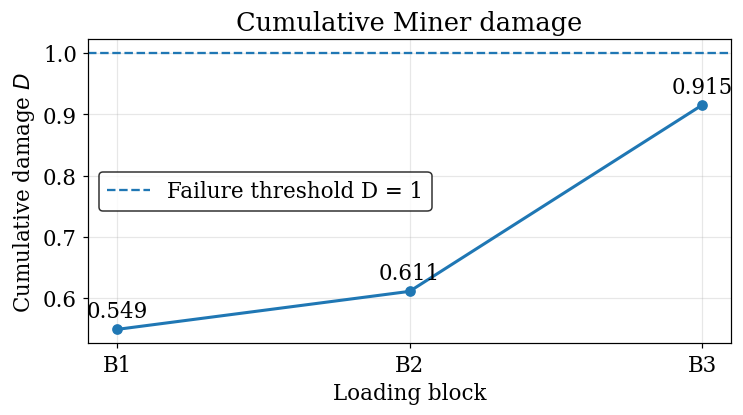

In [10]:

# ------------------------------------------------------------
# Plot 1 — damage contribution by block
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(df['Block'], df['Damage n/N_f'])
ax.axhline(1.0, linestyle='--', linewidth=1.5, label='Failure threshold D = 1')

ax.set_xlabel('Loading block')
ax.set_ylabel('Damage contribution $D_i = n_i/N_{f,i}$')
ax.set_title('Miner damage contribution per block')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2 — cumulative damage
# ------------------------------------------------------------

df['Cumulative damage'] = df['Damage n/N_f'].cumsum()

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df['Block'], df['Cumulative damage'], marker='o', linewidth=2)
ax.axhline(1.0, linestyle='--', linewidth=1.5, label='Failure threshold D = 1')

for i, row in df.iterrows():
    ax.annotate(
        f'{row["Cumulative damage"]:.3f}',
        (row['Block'], row['Cumulative damage']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

ax.set_xlabel('Loading block')
ax.set_ylabel('Cumulative damage $D$')
ax.set_title('Cumulative Miner damage')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

#### Solution summary — Exercise 5.4

| Quantity | Value |
|---|---:|
| Cumulative Miner damage $D = \sum n_i/N_{f,i}$ | 0.9151 |
| Does the component survive one spectrum? | Yes ($D < 1$) |
| Spectra to failure $1/D$ | 1.09 |

Block 1 ($\sigma_a = 300$ MPa, $\sigma_m = 150$ MPa, $n = 300\,000$ cycles) dominates the damage budget.
The spectrum nearly exhausts the fatigue life: only about one additional identical spectrum can be applied before predicted failure.

<a id='ex5'></a>
---

## Exercise 5.5 — Miner's rule: shortcomings

(a) The Miner rule has three well-known shortcomings. State them.

(b) Can these shortcomings lead to $\sum n/N$ values both smaller and larger than 1? Explain.

(c) The Miner rule ignores damage from cycles with amplitude below the fatigue limit. How can this be accounted for approximately? Is this correction fully rational?

(d) Is the sequence of cyclic loads significant for fatigue under variable-amplitude loading? Give an example.

### Solution

**(a) Three well-known shortcomings.**

1. **Sequence dependence** — Miner is linear, but the order of loading
   matters. High–low sequences (large amplitudes first) generally
   *accelerate* damage; low–high sequences *delay* it.
2. **Below-fatigue-limit damage** — Miner assumes no damage if $\sigma_a<\sigma_f$,
   but in spectrum loading the small cycles do propagate crack-like features
   once a damage state exists.
3. **Mean stress and overload effects** — Miner has no built-in mechanism for
   overloads / underloads, which produce retardation (compressive residual
   stresses at the crack tip) or acceleration.

**(b) Can $\sum n/N$ be ≠ 1?**

Yes: experimental data show $D_{\text{fail}}\in[0.3, 3]$ depending on the
sequence. Values $<1$ correspond to sequences where Miner overestimates life
(high-low); values $>1$ to sequences where Miner underestimates (low-high
retardation, ductile materials).

**(c) Cycles below the fatigue limit.**

EC3 Modified Miner: below the constant-amplitude fatigue limit, the curve is
*continued* with a steeper slope ($m'\ne m$), so small cycles contribute a
*small* but non-zero damage. This is **semi-empirical**, not derived from
mechanics — it is a calibration to make the rule less unsafe.

**(d) Sequence example.**

A **single overload** in service applies one large tension cycle, leaves a
compressive residual stress field at the crack tip, and the subsequent
constant-amplitude small cycles propagate the crack **slower** (Wheeler /
Willenborg models). Miner cannot predict this retardation.


<a id='ex6'></a>
---

## Exercise 5.6 — Estimating the S–N curve from $\sigma_u$


For a forged steel with $\sigma_u = 1000$ MPa:

(a) Estimate the fatigue limit ($R = -1$) using $\sigma_{f0} \approx 0.5\,\sigma_u$.

(b) Estimate the fatigue strength at $N_f = 10^3$ cycles using $\sigma_a(10^3) \approx 0.9\,\sigma_u$.

(c) Construct the estimated S--N curve (Basquin form) passing through these two points.

(d) Predict the fatigue strength at $N_f = 10^4$ cycles.

### Solution


(a) σ_f0 ≈ 0.5·σ_u = 500.0 MPa
(b) σ_a(1e3 cycles) ≈ 0.9·σ_u = 900.0 MPa
(c) Basquin fit:  σ_f' = 1718.4 MPa,  b = -0.0851
(d) σ_a(1e4) = σ_f' · (2·1e4)^b = 739.9 MPa


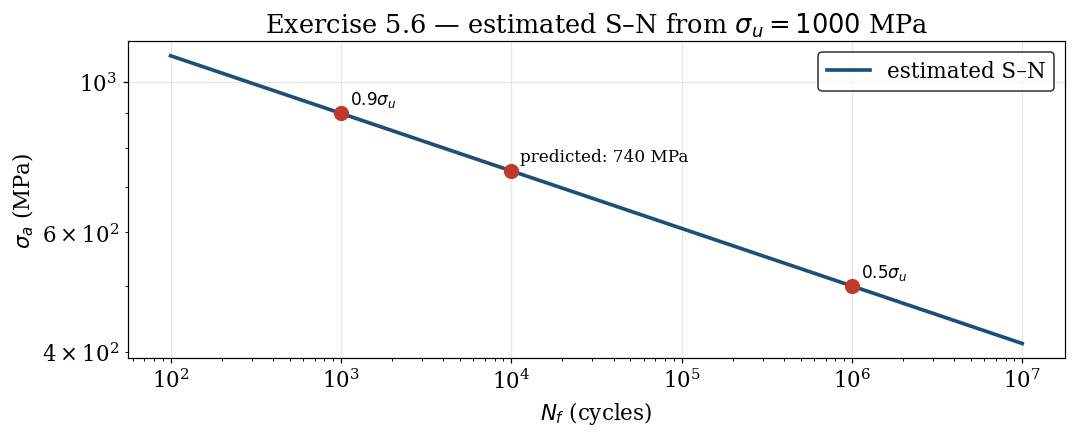

In [12]:
sigma_u = 1000.0

# (a) and (b): two anchor points
sigma_f0 = 0.5*sigma_u             # at N = ~1e6..1e7
sigma_a_1e3 = 0.9*sigma_u

# (c) Basquin σ_a = σ_f' (2 N_f)^b through two points: (2·1e3, 0.9σ_u) and (2·1e6, 0.5σ_u)
# Solve b and σ_f'
N1, sa1 = 1e3, sigma_a_1e3
N2, sa2 = 1e6, sigma_f0
b = np.log(sa1/sa2)/np.log(N1/N2)
sigma_fp = sa1/(2*N1)**b
print(f'(a) σ_f0 ≈ 0.5·σ_u = {sigma_f0:.1f} MPa')
print(f'(b) σ_a(1e3 cycles) ≈ 0.9·σ_u = {sigma_a_1e3:.1f} MPa')
print(f'(c) Basquin fit:  σ_f\' = {sigma_fp:.1f} MPa,  b = {b:.4f}')

# (d) predict σ_a at N = 1e4
N_d  = 1e4
sa_d = sigma_fp*(2*N_d)**b
print(f'(d) σ_a(1e4) = σ_f\' · (2·1e4)^b = {sa_d:.1f} MPa')

# Plot
N = np.logspace(2, 7, 400)
sa = sigma_fp*(2*N)**b
fig, ax = plt.subplots()
ax.loglog(N, sa, color=COLORS['curve'], lw=2.4, label='estimated S–N')
ax.scatter([N1, N2, N_d], [sa1, sa2, sa_d], color=COLORS['point'], s=80, zorder=5)
for x_,y_,lbl in [(N1, sa1, '$0.9\sigma_u$'), (N2, sa2, '$0.5\sigma_u$'),
                  (N_d, sa_d, f'predicted: {sa_d:.0f} MPa')]:
    ax.annotate(lbl, (x_, y_), xytext=(6,6), textcoords='offset points', fontsize=11)
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_title(r'Exercise 5.6 — estimated S–N from $\sigma_u=1000$ MPa')
ax.legend(); plt.tight_layout(); plt.show()


#### Solution summary — Exercise 5.6

| Quantity | Value |
|---|---:|
| Fatigue limit estimate $\sigma_{f0} \approx 0.5\,\sigma_u$ | 500 MPa |
| Strength at $10^3$ cycles $\approx 0.9\,\sigma_u$ | 900 MPa |
| Basquin exponent $b$ | $\approx -0.0851$ |
| Basquin coefficient $\sigma_f'$ | $\approx 1718$ MPa |
| Predicted $\sigma_a$ at $N_f = 10^4$ cycles | $\approx 739$ MPa |

The estimated S–N curve requires only $\sigma_u$ — no fatigue tests. The approximation is reliable for
wrought steels ($\sigma_u \lesssim 1400$ MPa) but tends to over-predict the fatigue limit for
higher-strength steels where inclusions control crack initiation.

<a id='ex7'></a>
---

## Exercise 5.7 — Residual stresses

(a) Give a definition of a residual stress distribution. What is characteristic about the equilibrium of a residual stress field?

(b) What is the effect of residual stresses on fatigue? Distinguish between compressive and tensile residual stresses.

(c) Residual stresses can be introduced intentionally (e.g. shot peening, plastic hole expansion) or unintentionally (production, heat treatment). Give one example of each.

### Solution

**(a) Definition.** Residual stresses are **self-equilibrated** stresses
present in a body in the absence of external loads. Their integral over any
section equals zero (force equilibrium) and so does the moment about any axis.
Hence a region of compressive residual stress is necessarily balanced by an
adjacent region of tensile residual stress.

**(b) Effect on fatigue.**

* **Compressive RS at the surface** are **beneficial**: they *subtract* from
  the applied tensile stress at the most fatigue-active location, reducing the
  effective $\sigma_{\max}$ and $\Delta\sigma_{\text{eff}}$. They are the
  reason shot-peening, cold-expansion of holes and laser-peening are widely
  used in aerospace.

* **Tensile RS** are detrimental: they shift the mean stress upwards at the
  surface, lowering the apparent fatigue limit. Weld residual stresses are
  almost always tensile and explain why **welded joints have S–N curves
  insensitive to the applied $R$** (the local $R$ at the weld toe is always
  $\sim 1$ regardless of nominal $R$).

**(c) Examples.**

* **Intentional:** shot peening of automotive springs (creates a ~0.3 mm
  compressive layer at the surface).
* **Unintentional:** quenching of a thick steel part — surface cools first and
  the core later, locking in **tensile** RS at the surface (unfavourable).
* **Intentional 2:** Split-sleeve cold expansion of fastener holes in aircraft
  skin — produces compressive RS that can extend fatigue life by an order of
  magnitude.


---

### Final remarks

* Soderberg gives the most conservative mean-stress correction (uses
  $\sigma_e$), Gerber the least (quadratic, $\sigma_u$). Goodman is the
  industry default for steels.
* Miner's rule is a **first** approximation; its predictions can be wrong by a
  factor of 2–3 either way and should be combined with sequence- and
  overload-aware models (Wheeler, Willenborg, strain-life PSWT).
* Compressive residual stresses are one of the few essentially free
  fatigue-life enhancements available to the designer.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.